In [100]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd


In [101]:
# Data Import
df = pd.read_csv("agriproductionkenya.csv")  # or read_excel if Excel

#Group by the type of crop
grouped = df.groupby('Crop')


In [102]:
features = []

for crop, data in grouped:
    # Sort by year
    data = data.sort_values("Year")
    X = data["Year"].values.reshape(-1,1)
    y = data["Value"].values
    
    # Guard against empty or zero series
    if len(y) < 2 or np.mean(y) == 0:
        continue
    
    # Slope (trend) normalized by mean
    model = LinearRegression().fit(X, y)
    slope = model.coef_[0] / np.mean(y)
    
    # Relative volatility (std of year-to-year changes / mean)
    volatility = np.std(np.diff(y) / np.mean(y))
    
    # CAGR (compound annual growth rate)
    cagr = (y[-1]/y[0])**(1/(len(y)-1)) - 1 if y[0] > 0 else 0
    
    # Stability index (coefficient of variation)
    stability = np.std(y) / np.mean(y)
    
    # Turning points (number of ups/downs)
    turning_points = np.sum(np.diff(np.sign(np.diff(y))) != 0)
    
    features.append([crop, slope, volatility, cagr, stability, turning_points])

features_df = pd.DataFrame(
    features,
    columns=["Crop","Slope","Volatility","CAGR","Stability","TurningPoints"]
)


In [103]:
X = features_df.drop("Crop", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [104]:
kmeans = KMeans(n_clusters=4, random_state=42)
features_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [105]:
features_df["Cluster"] = kmeans.fit_predict(X_scaled)

In [106]:
cluster_map = {
    0: "Steady growth crops",
    1: "Declining crops",
    2: "Volatile crops",
    3: "Stable but stagnant crops"
}

features_df["Category"] = features_df["Cluster"].map(cluster_map)


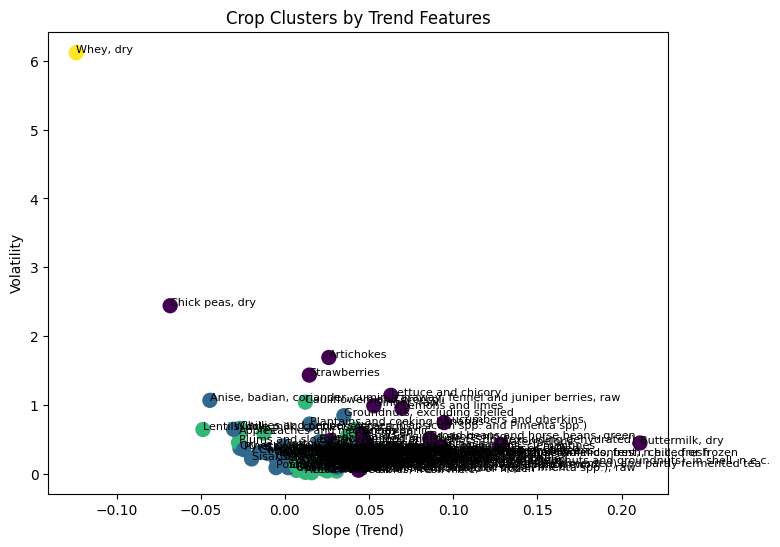

In [107]:

plt.figure(figsize=(8,6))
plt.scatter(features_df["Slope"], features_df["Volatility"], 
            c=features_df["Cluster"], cmap="viridis", s=100)

for i, crop in enumerate(features_df["Crop"]):
    plt.text(features_df["Slope"].iloc[i], features_df["Volatility"].iloc[i], crop, fontsize=8)

plt.xlabel("Slope (Trend)")
plt.ylabel("Volatility")
plt.title("Crop Clusters by Trend Features")
plt.show()


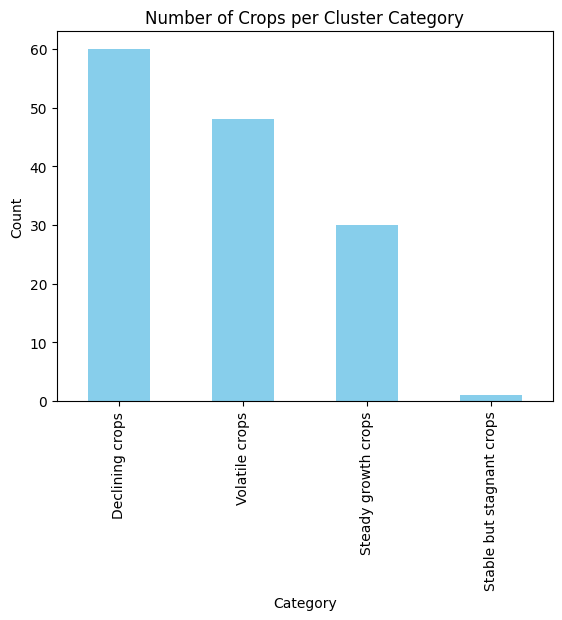

In [108]:
features_df["Category"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Number of Crops per Cluster Category")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_7970/2992113216.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_crops["Crop"], rotation=45, ha='right')
/tmp/ipykernel_7970/2992113216.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_crops["Crop"], rotation=45, ha='right')
/tmp/ipykernel_7970/2992113216.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_crops["Crop"], rotation=45, ha='right')
/tmp/ipykernel_7970/2992113216.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_crops["Crop"], rotation=45, ha='right')


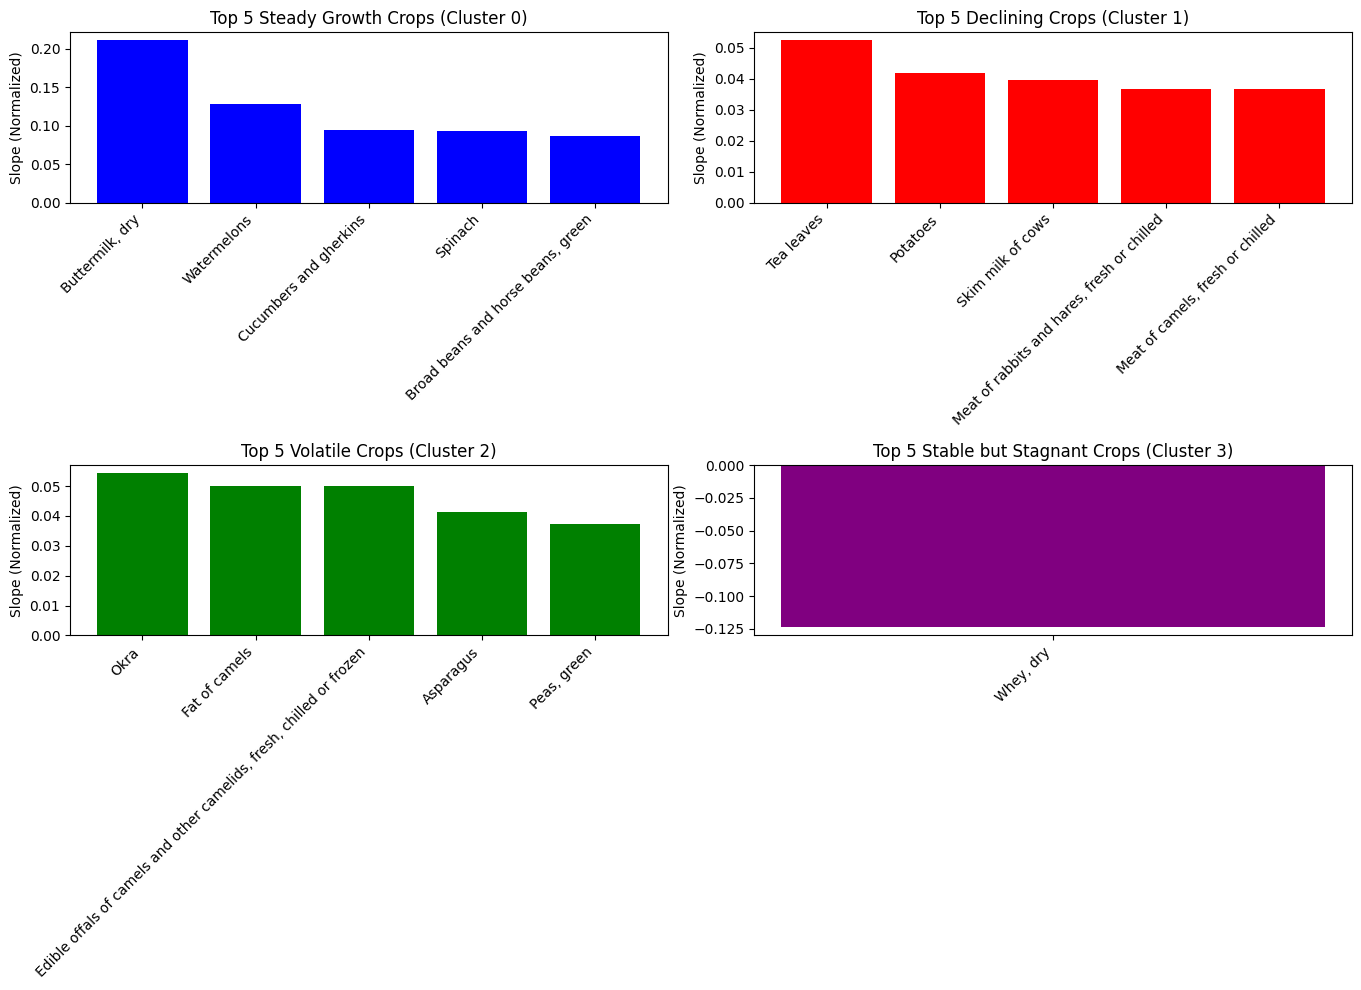

In [109]:

# Define cluster labels
cluster_map = {
    0: "Steady Growth Crops",
    1: "Declining Crops",
    2: "Volatile Crops",
    3: "Stable but Stagnant Crops"
}

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
colors = ['blue', 'red', 'green', 'purple']

for i, cluster_id in enumerate(sorted(features_df["Cluster"].unique())):
    # Get top 5 crops by slope (or change to CAGR, etc.)
    cluster_data = features_df[features_df["Cluster"] == cluster_id]
    top_crops = cluster_data.sort_values("Slope", ascending=False).head(5)
    
    # Plot
    ax = axs[i // 2, i % 2]
    ax.bar(top_crops["Crop"], top_crops["Slope"], color=colors[i])
    ax.set_title(f"Top 5 {cluster_map[cluster_id]} (Cluster {cluster_id})")
    ax.set_ylabel("Slope (Normalized)")
    ax.set_xticklabels(top_crops["Crop"], rotation=45, ha='right')

plt.tight_layout()
plt.show()